In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 제품 관련 데이터
products = pd.read_csv('../datasets/recommend/market/products.csv')
aisles = pd.read_csv('../datasets/recommend/market/aisles.csv')
departments = pd.read_csv('../datasets/recommend/market/departments.csv')

# 주문
orders = pd.read_csv('../datasets/recommend/market/orders.csv')
# 파일이 커서 100만 행만
order_products_prior = pd.read_csv('../datasets/recommend/market/order_products__prior.csv', nrows=1000000)
print(products.head())
print(orders.shape)
print(order_products_prior.shape)


   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id  
0             19  
1             13  
2              7  
3              1  
4             13  
(3421083, 7)
(1000000, 4)


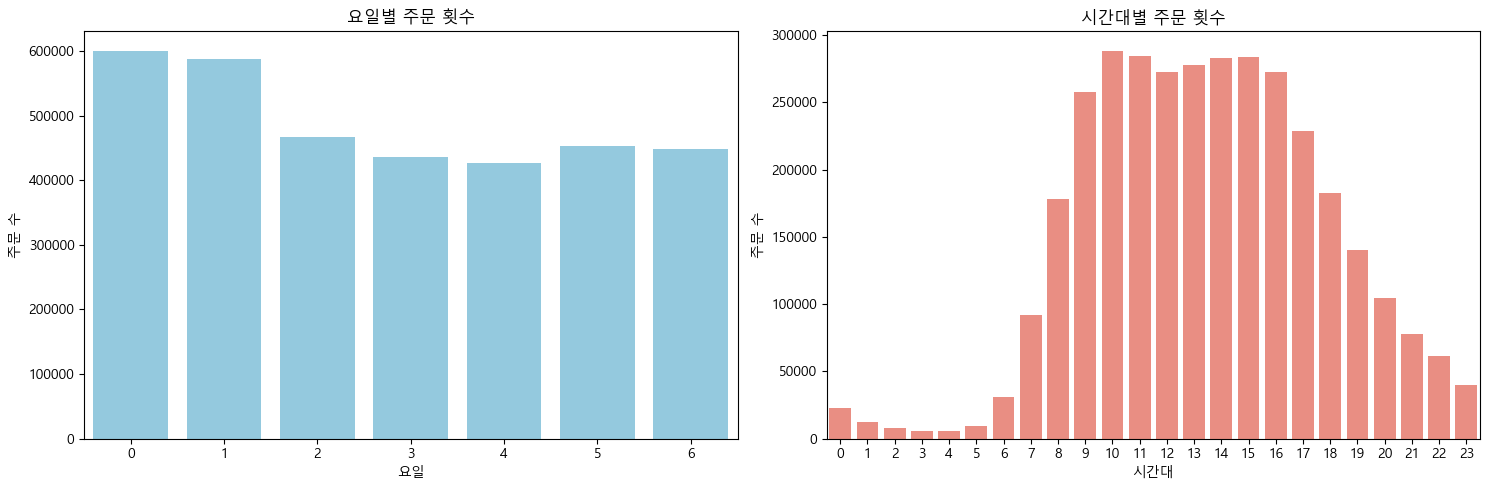

In [33]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 주문이 가장 많이 일어나는 요일과 시간대
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.countplot(x='order_dow', data = orders, color='skyblue')
plt.title('요일별 주문 횟수')
plt.xlabel('요일')
plt.ylabel('주문 수')

plt.subplot(1,2,2)
sns.countplot(x='order_hour_of_day', data=orders, color='salmon')
plt.title('시간대별 주문 횟수')
plt.xlabel('시간대')
plt.ylabel('주문 수')
plt.tight_layout()
plt.show()

C:\Users\301-23\AppData\Local\Temp\ipykernel_22232\740757826.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_30_products, y=top_30_products.index, palette='viridis')


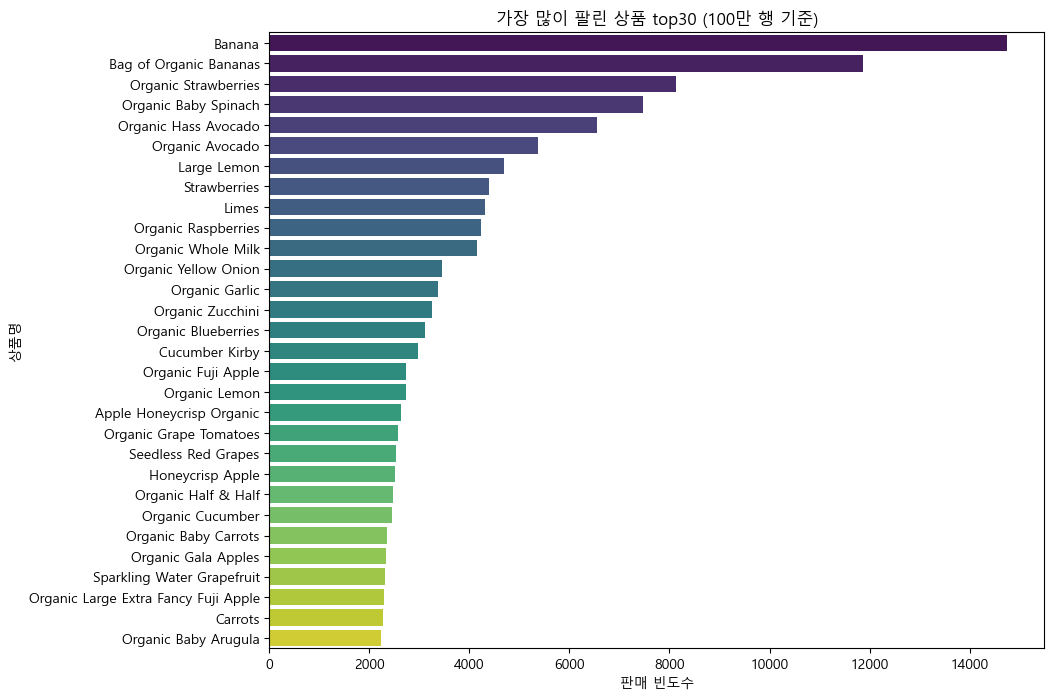

In [34]:
merge_df = pd.merge(order_products_prior, products, on='product_id', how='left')
top_30_products = merge_df['product_name'].value_counts().head(30)
plt.figure(figsize=(10,8))
sns.barplot(x=top_30_products, y=top_30_products.index, palette='viridis')
plt.title('가장 많이 팔린 상품 top30 (100만 행 기준)')
plt.xlabel('판매 빈도수')
plt.ylabel('상품명')
plt.show()

In [35]:
#order_id 기준으로 그룹핑
grouped = merge_df.groupby('order_id')['product_name'].apply(list).reset_index()
transactions = grouped['product_name'].tolist()
print(f'총 주문 수:{len(transactions)}')
print(f'처음 5개{transactions[:5]}')

총 주문 수:99260
처음 5개[['Organic Egg Whites', 'Michigan Organic Kale', 'Garlic Powder', 'Coconut Butter', 'Natural Sweetener', 'Carrots', 'Original Unflavored Gelatine Mix', 'All Natural No Stir Creamy Almond Butter', 'Classic Blend Cole Slaw'], ['Total 2% with Strawberry Lowfat Greek Strained Yogurt', 'Unsweetened Almondmilk', 'Lemons', 'Organic Baby Spinach', 'Unsweetened Chocolate Almond Breeze Almond Milk', 'Organic Ginger Root', 'Air Chilled Organic Boneless Skinless Chicken Breasts', 'Organic Ezekiel 49 Bread Cinnamon Raisin'], ['Plain Pre-Sliced Bagels', 'Honey/Lemon Cough Drops', 'Chewy 25% Low Sugar Chocolate Chip Granola', 'Oats & Chocolate Chewy Bars', "Kellogg's Nutri-Grain Apple Cinnamon Cereal", 'Nutri-Grain Soft Baked Strawberry Cereal Breakfast Bars', "Kellogg's Nutri-Grain Blueberry Cereal", 'Tiny Twists Pretzels', 'Traditional Snack Mix', 'Goldfish Cheddar Baked Snack Crackers', 'Original Orange Juice', 'Sugarfree Energy Drink', 'Energy Drink'], ['Bag of Organic Bananas',

In [36]:
#알고리즘이 빠르게 읽을 수있도록 true/false 매트릭스로 변환
!pip install mlxtend


In [41]:
from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_transactions = pd.DataFrame(te_ary, columns=te.columns_)
print(df_transactions.head())
print(df_transactions.shape)

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules
#최소 지지도
min_support = 0.01
# frequent_itemsets = apriori(df_transactions, min_support=min_support, use_colnames=True)
frequent_itemsets = fpgrowth(df_transactions, min_support=min_support, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False).reset_index(drop=True)
display(frequent_itemsets.head(20))
print(f'발견된 빈발패턴 아이템:{len(frequent_itemsets)}')

   #2 Coffee Filters  #2 Cone White Coffee Filters  \
0              False                         False   
1              False                         False   
2              False                         False   
3              False                         False   
4              False                         False   

   #4 Natural Brown Coffee Filters  & Go! Hazelnut Spread + Pretzel Sticks  \
0                            False                                   False   
1                            False                                   False   
2                            False                                   False   
3                            False                                   False   
4                            False                                   False   

   +Energy Black Cherry Vegetable & Fruit Juice  \
0                                         False   
1                                         False   
2                                         False   
3 

,support,itemsets
0,0.148690,frozenset({Banana})
1,0.119555,frozenset({Bag of Organic Bananas})
2,0.081987,frozenset({Organic Strawberries})
3,0.075327,frozenset({Organic Baby Spinach})
4,0.065998,frozenset({Organic Hass Avocado})
5,0.054191,frozenset({Organic Avocado})
6,0.047350,frozenset({Large Lemon})
7,0.044207,frozenset({Strawberries})
8,0.043492,frozenset({Limes})
9,0.042696,frozenset({Organic Raspberries})


발견된 빈발패턴 아이템:120


In [42]:
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
#최소 신뢰도 0.1로 설정하여 규칙도출
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.1)

rules= rules.sort_values('lift', ascending=False).reset_index(drop=True)
display(rules.head(20))


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({Organic Raspberries}),frozenset({Organic Strawberries}),0.042696,0.081987,0.010115,0.236904,2.889544,1.0,0.006614,1.203012,0.683090,0.088287,0.168753,0.180138
1,frozenset({Organic Strawberries}),frozenset({Organic Raspberries}),0.081987,0.042696,0.010115,0.123372,2.889544,1.0,0.006614,1.092030,0.712326,0.088287,0.084274,0.180138
2,frozenset({Organic Fuji Apple}),frozenset({Banana}),0.027594,0.148690,0.010326,0.374224,2.516803,1.0,0.006223,1.360407,0.619773,0.062223,0.264926,0.221837
3,frozenset({Bag of Organic Bananas}),frozenset({Organic Raspberries}),0.119555,0.042696,0.012795,0.107019,2.506548,1.0,0.007690,1.072032,0.682660,0.085608,0.067192,0.203345
4,frozenset({Organic Raspberries}),frozenset({Bag of Organic Bananas}),0.042696,0.119555,0.012795,0.299670,2.506548,1.0,0.007690,1.257186,0.627852,0.085608,0.204573,0.203345
5,frozenset({Organic Hass Avocado}),frozenset({Bag of Organic Bananas}),0.065998,0.119555,0.019101,0.289421,2.420829,1.0,0.011211,1.239054,0.628391,0.114756,0.192933,0.224596
6,frozenset({Bag of Organic Bananas}),frozenset({Organic Hass Avocado}),0.119555,0.065998,0.019101,0.159771,2.420829,1.0,0.011211,1.111603,0.666615,0.114756,0.100399,0.224596
7,frozenset({Organic Hass Avocado}),frozenset({Organic Strawberries}),0.065998,0.081987,0.012311,0.186536,2.275203,1.0,0.006900,1.128524,0.600083,0.090740,0.113887,0.168348
8,frozenset({Organic Strawberries}),frozenset({Organic Hass Avocado}),0.081987,0.065998,0.012311,0.150160,2.275203,1.0,0.006900,1.099032,0.610535,0.090740,0.090108,0.168348
9,frozenset({Organic Baby Spinach}),frozenset({Organic Hass Avocado}),0.075327,0.065998,0.010457,0.138826,2.103472,1.0,0.005486,1.084567,0.567331,0.079908,0.077973,0.148637
